# EuroSAT Land Cover Classification: ResNet50 vs ViT

This experiment fine-tunes pretrained ResNet50 and ViT models on EuroSAT and compares their land-cover classification performance.

## Environment setup

The experiment ran in Google Colab with a GPU. The following cell checks the active device.

In [2]:

!pip install -q datasets transformers accelerate evaluate scikit-learn torchvision huggingface_hub


In [3]:

import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU is not enabled. In Colab: Runtime → Change runtime type → GPU")


Device: cuda
GPU: Tesla T4


## Dataset: EuroSAT

The `cm93/eurosat` dataset contains 27,000 RGB Sentinel-2 images across 10 land-cover classes. It was loaded from the Hugging Face Hub with `load_dataset()`.

In [4]:

from datasets import load_dataset

dataset = load_dataset("cm93/eurosat")
dataset


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 21600
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
})

### Dataset splits and labels

In [5]:

print(dataset)

for split in dataset:
    print(f"{split}: {len(dataset[split]):,} images")

labels = dataset["train"].features["label"].names
print("\nClasses:")
for i, label in enumerate(labels):
    print(i, label)


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 21600
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
})
train: 21,600 images
validation: 2,700 images
test: 2,700 images

Classes:
0 Forest
1 River
2 Highway
3 AnnualCrop
4 SeaLake
5 HerbaceousVegetation
6 Industrial
7 Residential
8 PermanentCrop
9 Pasture


## Exploratory Data Analysis (EDA)


In [6]:

import pandas as pd

train_labels = dataset["train"]["label"]

class_counts = (
    pd.Series(train_labels)
    .value_counts()
    .sort_index()
    .rename(index=dict(enumerate(labels)))
)

class_counts


,count
Forest,2400
River,2000
Highway,2000
AnnualCrop,2400
SeaLake,2400
HerbaceousVegetation,2400
Industrial,2000
Residential,2400
PermanentCrop,2000
Pasture,1600


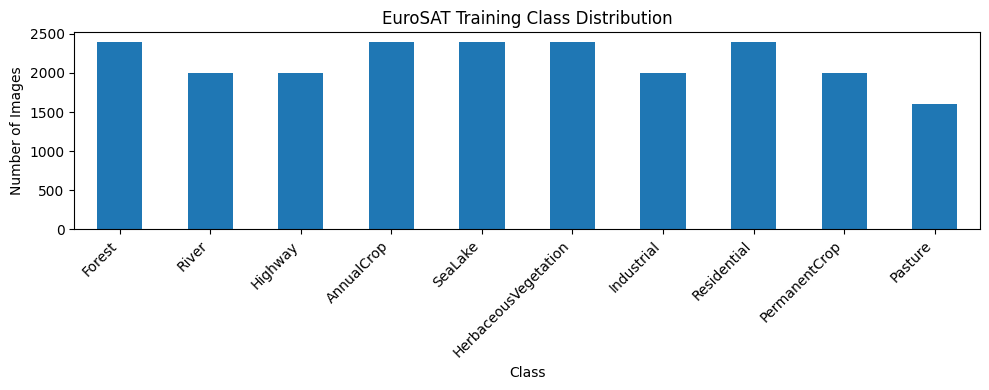

In [7]:

import matplotlib.pyplot as plt

class_counts.plot(kind="bar", figsize=(10, 4))
plt.title("EuroSAT Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Sample images

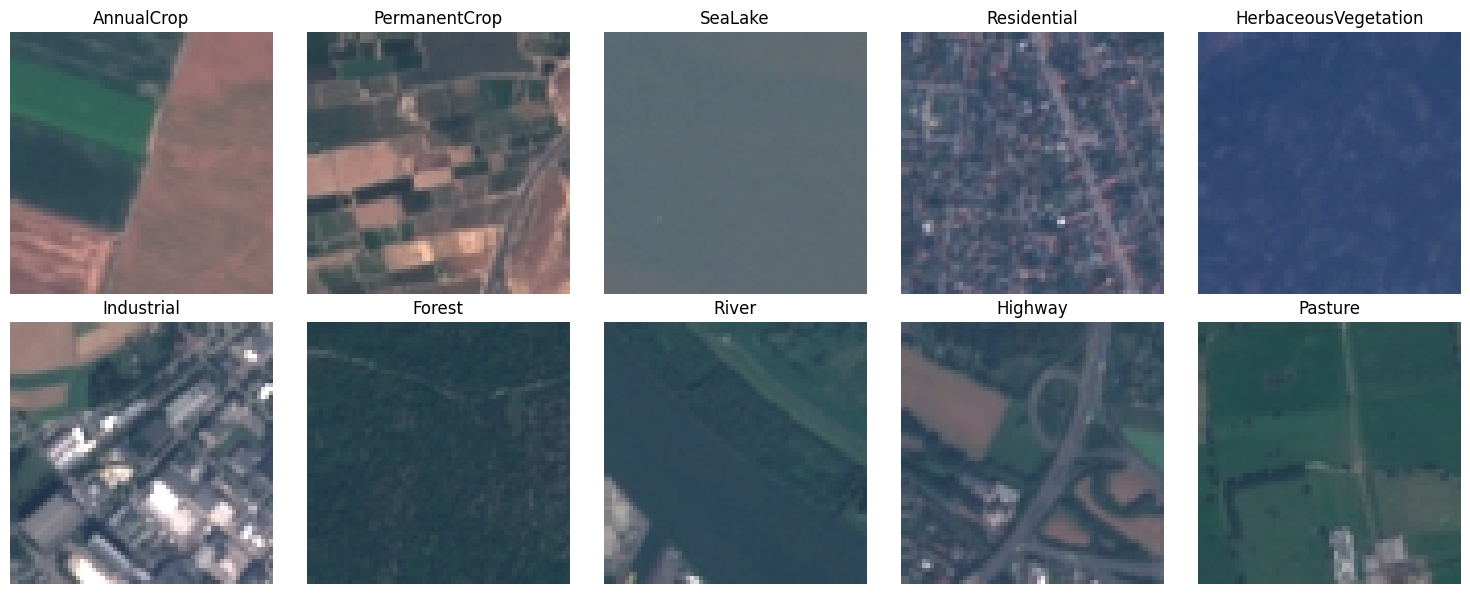

In [8]:

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

seen = set()
samples = []

for example in dataset["train"]:
    label_id = example["label"]
    if label_id not in seen:
        samples.append(example)
        seen.add(label_id)
    if len(samples) == len(labels):
        break

for ax, example in zip(axes.flatten(), samples):
    ax.imshow(example["image"])
    ax.set_title(labels[example["label"]])
    ax.axis("off")

plt.tight_layout()
plt.show()


### EDA observations

- The training split is slightly imbalanced, with 1,600 to 2,400 images per class.
- Crop and vegetation classes have similar colors and textures.
- `Industrial`, `Residential`, and `Highway` share some built-environment patterns.
- Forest and water classes look more distinct in the sample images.

## Experiment design

Both models used the same train, validation, and test splits.

- **ResNet50:** pretrained ImageNet weights with a new 10-class output layer.
- **ViT Base Patch16-224:** pretrained `google/vit-base-patch16-224` with a 10-class output layer.

The models were compared using accuracy, macro F1, per-class metrics, and confusion matrices.

In [9]:

id2label = {i: label for i, label in enumerate(labels)}
label2id = {label: i for i, label in enumerate(labels)}

NUM_LABELS = len(labels)
NUM_LABELS


10

## ResNet50 fine-tuning

The pretrained ResNet50 output layer was replaced with a 10-class classifier, then the full model was fine-tuned.

In [10]:

import torchvision
from torchvision.models import ResNet50_Weights
from torchvision import transforms
from torch import nn
from torch.utils.data import DataLoader
import time
import numpy as np

resnet_weights = ResNet50_Weights.DEFAULT
resnet_transform = resnet_weights.transforms()

resnet = torchvision.models.resnet50(weights=resnet_weights)
resnet.fc = nn.Linear(resnet.fc.in_features, NUM_LABELS)
resnet = resnet.to(device)

print(resnet.fc)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 116MB/s]


Linear(in_features=2048, out_features=10, bias=True)


### ResNet50 data preparation

In [11]:

class HFDatasetForTorch(torch.utils.data.Dataset):
    def __init__(self, hf_split, transform):
        self.data = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        image = self.transform(image)
        label = item["label"]
        return image, label

resnet_train_ds = HFDatasetForTorch(dataset["train"], resnet_transform)
resnet_val_ds = HFDatasetForTorch(dataset["validation"], resnet_transform)
resnet_test_ds = HFDatasetForTorch(dataset["test"], resnet_transform)

BATCH_SIZE = 32

resnet_train_loader = DataLoader(resnet_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
resnet_val_loader = DataLoader(resnet_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
resnet_test_loader = DataLoader(resnet_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


### ResNet50 training configuration

Training used 3 epochs, AdamW, and a learning rate of 1e-4.

In [12]:

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(resnet.parameters(), lr=1e-4)
EPOCHS = 3


In [13]:

def evaluate_torch_model(model, loader):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for images, labels_batch in loader:
            images = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images)
            batch_preds = outputs.argmax(dim=1)

            preds.extend(batch_preds.cpu().numpy())
            targets.extend(labels_batch.cpu().numpy())

    return np.array(targets), np.array(preds)


In [14]:

resnet_start = time.time()

for epoch in range(EPOCHS):
    resnet.train()
    running_loss = 0.0

    for images, labels_batch in resnet_train_loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = resnet(images)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {running_loss / len(resnet_train_loader):.4f}")

resnet_training_time = time.time() - resnet_start
print(f"Training time: {resnet_training_time/60:.2f} minutes")


Epoch 1/3 | Loss: 0.3082
Epoch 2/3 | Loss: 0.0827
Epoch 3/3 | Loss: 0.0546
Training time: 11.44 minutes


### ResNet50 evaluation

In [15]:

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

resnet_y_true, resnet_y_pred = evaluate_torch_model(resnet, resnet_test_loader)

resnet_accuracy = accuracy_score(resnet_y_true, resnet_y_pred)
resnet_f1 = f1_score(resnet_y_true, resnet_y_pred, average="macro")

print("ResNet50 Accuracy:", resnet_accuracy)
print("ResNet50 Macro F1:", resnet_f1)
print()
print(classification_report(resnet_y_true, resnet_y_pred, target_names=labels))


ResNet50 Accuracy: 0.9740740740740741
ResNet50 Macro F1: 0.9735837413668055

                      precision    recall  f1-score   support

              Forest       0.99      0.99      0.99       300
               River       0.97      1.00      0.98       250
             Highway       1.00      0.96      0.98       250
          AnnualCrop       0.98      0.97      0.97       300
             SeaLake       0.99      1.00      1.00       300
HerbaceousVegetation       0.97      0.93      0.95       300
          Industrial       1.00      0.95      0.97       250
         Residential       0.96      1.00      0.98       300
       PermanentCrop       0.92      0.97      0.95       250
             Pasture       0.96      0.97      0.97       200

            accuracy                           0.97      2700
           macro avg       0.97      0.97      0.97      2700
        weighted avg       0.97      0.97      0.97      2700



## Vision Transformer fine-tuning

The pretrained ViT classification head was adapted to 10 classes. Images were processed with the checkpoint's image processor before fine-tuning.

In [16]:

from transformers import AutoImageProcessor, AutoModelForImageClassification

vit_checkpoint = "google/vit-base-patch16-224"

vit_processor = AutoImageProcessor.from_pretrained(vit_checkpoint)

vit = AutoModelForImageClassification.from_pretrained(
    vit_checkpoint,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

print("ViT loaded.")


ViT loaded.


In [17]:

def vit_transform(example_batch):
    images = [img.convert("RGB") for img in example_batch["image"]]
    inputs = vit_processor(images=images, return_tensors="pt")
    inputs["labels"] = example_batch["label"]
    return inputs

vit_dataset = dataset.with_transform(vit_transform)


In [18]:

import evaluate

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, label_ids = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(label_ids, predictions)
    macro_f1 = f1_score(label_ids, predictions, average="macro")

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
    }


### ViT training configuration

ViT was trained for 3 epochs with a learning rate of 5e-5, weight decay of 0.01, and batch size 16. The best validation checkpoint was selected by macro F1.

In [19]:

from transformers import TrainingArguments, Trainer, DefaultDataCollator

vit_training_args = TrainingArguments(
    output_dir="./vit-eurosat",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    remove_unused_columns=False,
    report_to="none",
)

vit_trainer = Trainer(
    model=vit,
    args=vit_training_args,
    train_dataset=vit_dataset["train"],
    eval_dataset=vit_dataset["validation"],
    processing_class=vit_processor,
    data_collator=DefaultDataCollator(),
    compute_metrics=compute_metrics,
)


In [20]:

vit_start = time.time()

vit_trainer.train()

vit_training_time = time.time() - vit_start
print(f"ViT training time: {vit_training_time/60:.2f} minutes")


ViT training time: 42.19 minutes


### ViT evaluation

In [21]:

vit_test_results = vit_trainer.evaluate(vit_dataset["test"])
vit_test_results


{'eval_loss': 0.04449528455734253,
 'eval_accuracy': 0.987037037037037,
 'eval_macro_f1': 0.9866576871403636}

In [22]:

vit_predictions = vit_trainer.predict(vit_dataset["test"])

vit_y_true = vit_predictions.label_ids
vit_y_pred = np.argmax(vit_predictions.predictions, axis=1)

vit_accuracy = accuracy_score(vit_y_true, vit_y_pred)
vit_f1 = f1_score(vit_y_true, vit_y_pred, average="macro")

print("ViT Accuracy:", vit_accuracy)
print("ViT Macro F1:", vit_f1)
print()
print(classification_report(vit_y_true, vit_y_pred, target_names=labels))


ViT Accuracy: 0.987037037037037
ViT Macro F1: 0.9866576871403636

                      precision    recall  f1-score   support

              Forest       0.99      1.00      1.00       300
               River       0.99      1.00      0.99       250
             Highway       0.99      0.98      0.99       250
          AnnualCrop       0.99      0.98      0.98       300
             SeaLake       1.00      1.00      1.00       300
HerbaceousVegetation       0.96      0.99      0.98       300
          Industrial       0.98      0.99      0.99       250
         Residential       1.00      0.99      0.99       300
       PermanentCrop       0.98      0.96      0.97       250
             Pasture       0.98      0.98      0.98       200

            accuracy                           0.99      2700
           macro avg       0.99      0.99      0.99      2700
        weighted avg       0.99      0.99      0.99      2700



## Model comparison

In [23]:

comparison = pd.DataFrame({
    "Model": ["ResNet50", "ViT Base"],
    "Accuracy": [resnet_accuracy, vit_accuracy],
    "Macro F1": [resnet_f1, vit_f1],
    "Training Time (min)": [
        resnet_training_time / 60,
        vit_training_time / 60
    ]
})

comparison


,Model,Accuracy,Macro F1,Training Time (min)
0,ResNet50,0.974074,0.973584,11.443375
1,ViT Base,0.987037,0.986658,42.186213


### Confusion matrices

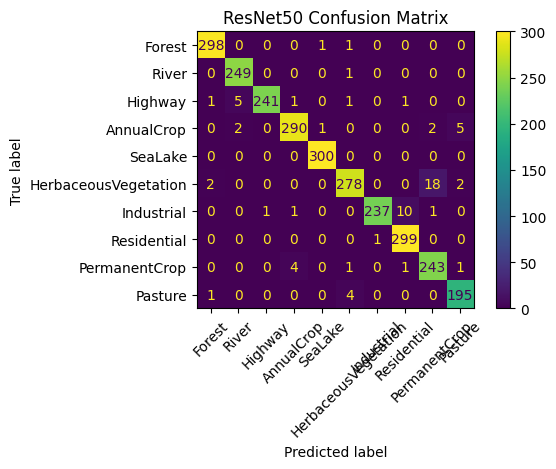

In [24]:

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    resnet_y_true,
    resnet_y_pred,
    display_labels=labels,
    xticks_rotation=45
)
plt.title("ResNet50 Confusion Matrix")
plt.tight_layout()
plt.show()


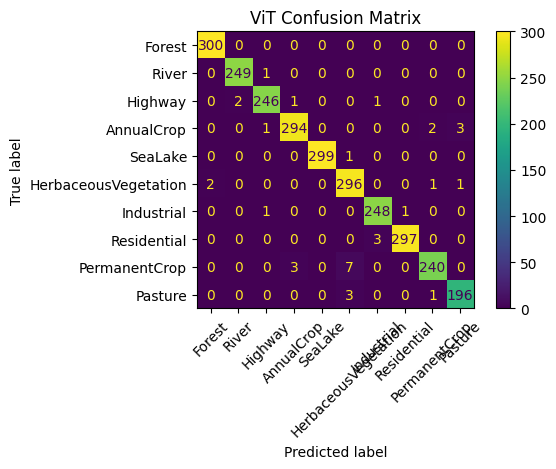

In [25]:

ConfusionMatrixDisplay.from_predictions(
    vit_y_true,
    vit_y_pred,
    display_labels=labels,
    xticks_rotation=45
)
plt.title("ViT Confusion Matrix")
plt.tight_layout()
plt.show()


## Error analysis

ResNet50's lowest per-class F1 scores were 0.95 for `HerbaceousVegetation` and `PermanentCrop`. ViT reduced these errors; its lowest per-class F1 was 0.97 for `PermanentCrop`.

ViT achieved the higher macro F1, while ResNet50 trained faster: 11.44 minutes compared with 42.19 minutes for ViT.

## Conclusion

ViT achieved 98.7037% accuracy and 98.6658% macro F1, compared with 97.4074% accuracy and 97.3584% macro F1 for ResNet50. ViT performed better in this experiment, while ResNet50 trained considerably faster. Both pretrained models transferred effectively to EuroSAT.

### Possible next steps

- Inspect misclassified images.
- Compare inference speed and model size.
- Add explainability visualizations.